# **Importing libraries**

Implementare Time Stretching, Pitch Shifting, Compressione (DRC) e Iniezione di Rumore (BG) per migliorare la robustezza del modello e limitare l'overfitting.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import sys
import librosa
import torchvision
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset
import random

import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd

from tqdm import tqdm
%matplotlib inline

from torchsummary import summary
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

from torch.utils.data import Dataset
import glob


# Get Computational Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Importing the Dataset

In [3]:
# Percorso base del dataset RAVDESS su Kaggle
# (Kaggle salva automaticamente i dataset nella cartella /kaggle/input/)
DATASET_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"
emotion_map = {
    0: "neutral", 1: "calm", 2: "happy", 3: "sad",
    4: "angry", 5: "fearful", 6: "disgust", 7: "surprised"
}

# Data Augmentation

Creazione di una funzione di supporto per la rappresentazione grafica di segnali aumentati multipli

In [4]:
def _plot_signal_and_augmented_signal(signal, augmented_signal, sr):
    fig, ax = plt.subplots(nrows=2)
    librosa.display.waveplot(signal, sr=sr, ax=ax[0])
    ax[0].set(title="Original signal")
    librosa.display.waveplot(augmented_signal, sr=sr, ax=ax[1])
    ax[1].set(title="Augmented signal")
    plt.show()

Implementare Time Stretching, Pitch Shifting, Compressione (DRC) e Iniezione di Rumore (BG) per migliorare la robustezza del modello e limitare l'overfitting.

> **Fix applicati:**
> - `random_gain`: range corretto da `(0.1, 0.12)` → `(0.7, 1.3)` (era un bug che attenuava il segnale al 10%)
> - `add_white_noise`: rumore variabile (SNR casuale tra 20–40 dB)

In [5]:
class SpecAugment(nn.Module):
    """
    Applica SpecAugment a batch di log-mel spectrogram con shape (B, 1, n_mels, time).
    Parametri aumentati rispetto alla versione base per maggiore regolarizzazione.
    """
    def __init__(self, freq_mask_param: int = 15, time_mask_param: int = 30,
                 n_time_masks: int = 2, iid_masks: bool = True):
        super().__init__()
        self.freq_masking = T.FrequencyMasking(freq_mask_param=freq_mask_param)
        self.time_maskings = nn.ModuleList([
            T.TimeMasking(time_mask_param=time_mask_param, iid_masks=iid_masks)
            for _ in range(n_time_masks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.freq_masking(x)
        for tm in self.time_maskings:
            x = tm(x)
        return x


# Parametri aumentati: freq_mask=15 (era 10), time_mask=30 (era 20), n_masks=2 (era 1)
spec_augment = SpecAugment(
    freq_mask_param=15,
    time_mask_param=30,
    n_time_masks=2,
    iid_masks=True
).to(device)

print('SpecAugment pronto:', spec_augment)


SpecAugment pronto: SpecAugment(
  (freq_masking): FrequencyMasking()
  (time_maskings): ModuleList(
    (0-1): 2 x TimeMasking()
  )
)


In [6]:
# Creiamo le cartelle fisiche sull'Hard Disk di Kaggle
os.makedirs('/kaggle/working/processed_data/train', exist_ok=True)
os.makedirs('/kaggle/working/processed_data/val', exist_ok=True)
os.makedirs('/kaggle/working/processed_data/test', exist_ok=True)

# Data Augmentation — funzioni base + mirate per emozioni a bassa intensità

> **Nuovo:** `neutral` (0) e `sad` (3) ricevono augmentation specifica basata
> sulle loro caratteristiche acustiche: pitch verso il basso, tempo rallentato,
> guadagno ridotto.

In [7]:
# ── Augmentation generiche ───────────────────────────────────────────────────

def apply_time_stretch(wav, rate):
    return librosa.effects.time_stretch(y=wav, rate=rate)

def apply_pitch_shift(wav, sr, n_steps):
    return librosa.effects.pitch_shift(y=wav, sr=sr, n_steps=n_steps)

def add_white_noise(signal):
    """Rumore bianco con SNR casuale tra 20 e 40 dB."""
    snr_db = random.uniform(20, 40)
    signal_power = np.mean(signal ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

def random_gain(signal, min_factor=0.7, max_factor=1.3):
    """Variazione di guadagno ±30%."""
    return signal * random.uniform(min_factor, max_factor)

# ── Augmentation specifiche per emozioni a bassa intensità ───────────────────

LOW_INTENSITY_CLASSES = {0, 3}   # 0 = neutral, 3 = sad

def low_energy_gain(signal):
    """
    Simula speech a bassa intensità: guadagno ridotto (0.4–0.65).
    Tipico di neutral/sad che parlano sottovoce o con poco slancio.
    """
    factor = random.uniform(0.40, 0.65)
    return signal * factor

def sad_pitch_shift(wav, sr):
    """
    Pitch shift verso il basso (-4 ÷ -1 semitoni).
    Il parlato triste è caratterizzato da F0 basso e cadente.
    """
    steps = random.uniform(-4.0, -1.0)
    return librosa.effects.pitch_shift(y=wav, sr=sr, n_steps=steps)

def sad_time_stretch(wav):
    """
    Time stretch rallentato (0.75–0.92).
    Sad speech ha articolazione lenta e pause più lunghe.
    """
    rate = random.uniform(0.75, 0.92)
    return librosa.effects.time_stretch(y=wav, rate=rate)

def neutral_pitch_micro(wav, sr):
    """
    Micro-variazione di pitch per neutral (±1 semitono).
    Neutral è quasi piatto: piccoli spostamenti ne rafforzano la varietà.
    """
    steps = random.uniform(-1.0, 1.0)
    return librosa.effects.pitch_shift(y=wav, sr=sr, n_steps=steps)

def neutral_time_micro(wav):
    """
    Time stretch vicino a 1× per neutral (0.93–1.07).
    Preserva il ritmo neutro ma introduce variabilità minima.
    """
    rate = random.uniform(0.93, 1.07)
    return librosa.effects.time_stretch(y=wav, rate=rate)

def add_soft_noise(signal):
    """
    Rumore molto leggero (SNR 35–50 dB): simula la qualità breathiness
    tipica di parlato neutro o triste registrato in ambiente non-anecoico.
    """
    snr_db = random.uniform(35, 50)
    signal_power = np.mean(signal ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

print("Funzioni di augmentation caricate (generiche + mirate neutral/sad).")


Funzioni di augmentation caricate (generiche + mirate neutral/sad).


In [8]:
class SpecAugment(nn.Module):
    """
    Applica SpecAugment a batch di log-mel spectrogram con shape (B, 1, n_mels, time).
    Parametri aumentati rispetto alla versione base per maggiore regolarizzazione.
    """
    def __init__(self, freq_mask_param: int = 15, time_mask_param: int = 30,
                 n_time_masks: int = 2, iid_masks: bool = True):
        super().__init__()
        self.freq_masking = T.FrequencyMasking(freq_mask_param=freq_mask_param)
        self.time_maskings = nn.ModuleList([
            T.TimeMasking(time_mask_param=time_mask_param, iid_masks=iid_masks)
            for _ in range(n_time_masks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.freq_masking(x)
        for tm in self.time_maskings:
            x = tm(x)
        return x


# Parametri aumentati: freq_mask=15 (era 10), time_mask=30 (era 20), n_masks=2 (era 1)
spec_augment = SpecAugment(
    freq_mask_param=15,
    time_mask_param=30,
    n_time_masks=2,
    iid_masks=True
).to(device)

print('SpecAugment pronto:', spec_augment)


SpecAugment pronto: SpecAugment(
  (freq_masking): FrequencyMasking()
  (time_maskings): ModuleList(
    (0-1): 2 x TimeMasking()
  )
)


In [9]:
# Creiamo le cartelle fisiche sull'Hard Disk di Kaggle
os.makedirs('/kaggle/working/processed_data/train', exist_ok=True)
os.makedirs('/kaggle/working/processed_data/val', exist_ok=True)
os.makedirs('/kaggle/working/processed_data/test', exist_ok=True)

### Generazione dataset aumentato

> **Strategia per neutral (0) e sad (3):**
> - Stessi augmentation standard delle altre classi
> - **+7 campioni extra** per campione originale:
>   - 3× pitch basso casuale (`sad_pitch_shift`)
>   - 2× time stretch lento (`sad_time_stretch` per sad, `neutral_time_micro` per neutral)
>   - 1× guadagno ridotto (`low_energy_gain`)
>   - 1× rumore soffice (`add_soft_noise`)
> 
> Le altre 6 classi mantengono i **16 aug standard**. Neutral e sad avranno **23 aug**,
> portando il loro training set a circa 1.44× rispetto alle altre classi.

### Segmentazione delle registrazioni audio

In questa versione, prima di calcolare il Mel-spectrogram, ogni audio viene diviso in segmenti di durata fissa pari a **3 secondi** con **50% di overlap**.

Se un file è più corto di 3 secondi viene completato con zero-padding; se è più lungo vengono generati più segmenti, tutti con la stessa label e lo stesso speaker dell'utterance originale.

Questa modifica aumenta il numero effettivo di esempi visti dal modello e può aiutare a ridurre l'overfitting, perché la CRNN osserva porzioni temporali più locali e omogenee invece dell'intera registrazione.


In [10]:
def segment_audio(wav, sample_rate, segment_duration=3.0, overlap=0.5):
    """
    Divide un audio 1D in segmenti di durata fissa.

    Parametri:
    - segment_duration=3.0 secondi
    - overlap=0.5 -> 50% di sovrapposizione tra segmenti consecutivi

    Se l'audio è più corto di segment_duration, viene fatto zero-padding.
    Restituisce una lista di array numpy 1D.
    """
    segment_len = int(segment_duration * sample_rate)
    hop_len = int(segment_len * (1.0 - overlap))

    if hop_len <= 0:
        raise ValueError("overlap troppo alto: hop_len deve essere > 0")

    # Caso audio troppo corto: padding a 3 secondi
    if len(wav) < segment_len:
        padded = np.zeros(segment_len, dtype=np.float32)
        padded[:len(wav)] = wav
        return [padded]

    segments = []
    for start in range(0, len(wav) - segment_len + 1, hop_len):
        segment = wav[start:start + segment_len]
        segments.append(segment.astype(np.float32))

    # Se resta una coda non coperta, aggiungo un ultimo segmento allineato alla fine.
    # Evita di perdere informazione negli ultimi istanti dell'utterance.
    last_start = len(wav) - segment_len
    if len(segments) == 0 or last_start > (len(segments) - 1) * hop_len:
        segment = wav[last_start:last_start + segment_len]
        segments.append(segment.astype(np.float32))

    return segments


def generate_augmented_dataset_ondisk(root_dir=DATASET_PATH):

    import shutil

    # IMPORTANTE: pulisco le cartelle per evitare di mischiare vecchi .pt non segmentati
    # con i nuovi .pt segmentati quando si riesegue il notebook.
    processed_root = "/kaggle/working/processed_data"
    for subset_name in ["train", "val", "test"]:
        subset_dir = os.path.join(processed_root, subset_name)
        if os.path.exists(subset_dir):
            shutil.rmtree(subset_dir)
        os.makedirs(subset_dir, exist_ok=True)

    counters = {'train': 0, 'val': 0, 'test': 0}
    original_files_per_subset = {'train': 0, 'val': 0, 'test': 0}
    original_segments_per_subset = {'train': 0, 'val': 0, 'test': 0}

    all_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith(".wav"):
                all_files.append(os.path.join(dirpath, f))

    for file_path in tqdm(all_files, desc="Estrazione, segmentazione e salvataggio (16kHz)"):
        filename = os.path.basename(file_path)
        parts = filename.replace(".wav", "").split("-")

        if len(parts) != 7:
            continue

        emotion_label = int(parts[2]) - 1
        speaker_id    = int(parts[6])

        waveform, sample_rate = torchaudio.load(file_path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sample_rate != 16000:
            resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform   = resampler(waveform)
            sample_rate = 16000

        wav_np = waveform.squeeze().numpy()
        wav_trimmed, _ = librosa.effects.trim(wav_np, top_db=30)
        wav_orig = librosa.util.normalize(wav_trimmed)

        if speaker_id <= 18:
            subset = "train"
        elif 19 <= speaker_id <= 22:
            subset = "val"
        else:
            subset = "test"

        original_files_per_subset[subset] += 1

        # ── Segmentazione: ogni utterance diventa una lista di segmenti da 3s con 50% overlap ──
        segments = segment_audio(
            wav_orig,
            sample_rate=sample_rate,
            segment_duration=3.0,
            overlap=0.5
        )
        original_segments_per_subset[subset] += len(segments)

        def save_file(wav_data, subset_name):
            path = f"/kaggle/working/processed_data/{subset_name}/sample_{counters[subset_name]}.pt"
            wav_data = np.asarray(wav_data, dtype=np.float32)
            torch.save((wav_data, sample_rate, emotion_label, speaker_id), path)
            counters[subset_name] += 1

        # Salvo e aumento ogni segmento separatamente.
        # In questo modo il modello vede porzioni locali dell'utterance.
        for wav_segment in segments:

            # ── Salva segmento originale ──────────────────────────────────────
            save_file(wav_segment, subset)

            # ── Augmentation solo per train ───────────────────────────────────
            if subset == "train":

                # ── Standard (tutte le classi) — 16 aug per segmento ─────────
                for rate in [0.81, 0.93, 1.07, 1.23]:
                    aug = apply_time_stretch(wav_segment, rate)
                    aug = librosa.util.fix_length(aug, size=len(wav_segment))
                    save_file(librosa.util.normalize(aug), "train")

                for steps in [-3.5, -2.5, -2, -1, 1, 2, 2.5, 3.5]:
                    aug = apply_pitch_shift(wav_segment, sample_rate, steps)
                    aug = librosa.util.fix_length(aug, size=len(wav_segment))
                    save_file(librosa.util.normalize(aug), "train")

                for _ in range(2):
                    aug = add_white_noise(wav_segment)
                    save_file(librosa.util.normalize(aug), "train")

                for _ in range(2):
                    aug = random_gain(wav_segment)
                    save_file(librosa.util.normalize(aug), "train")

                # ── Augmentation mirata: neutral (0) e sad (3) — +7 aug per segmento ──
                if emotion_label in LOW_INTENSITY_CLASSES:

                    # 3 pitch shift verso il basso (enfatizza F0 basso)
                    for _ in range(3):
                        aug = sad_pitch_shift(wav_segment, sample_rate)
                        aug = librosa.util.fix_length(aug, size=len(wav_segment))
                        save_file(librosa.util.normalize(aug), "train")

                    # 2 time stretch lento / micro-variazione ritmo
                    if emotion_label == 3:   # sad → stretch molto lento
                        for _ in range(2):
                            aug = sad_time_stretch(wav_segment)
                            aug = librosa.util.fix_length(aug, size=len(wav_segment))
                            save_file(librosa.util.normalize(aug), "train")
                    else:                    # neutral → micro-variazione ritmo
                        for _ in range(2):
                            aug = neutral_time_micro(wav_segment)
                            aug = librosa.util.fix_length(aug, size=len(wav_segment))
                            save_file(librosa.util.normalize(aug), "train")

                    # 1 guadagno ridotto (bassa intensità energetica)
                    aug = low_energy_gain(wav_segment)
                    save_file(librosa.util.normalize(aug), "train")

                    # 1 rumore soffice (breathiness / qualità flat)
                    aug = add_soft_noise(wav_segment)
                    save_file(librosa.util.normalize(aug), "train")

    print("\nSalvataggio completato con segmentazione!")
    print(f"File originali -> Train: {original_files_per_subset['train']}, "
          f"Val: {original_files_per_subset['val']}, "
          f"Test: {original_files_per_subset['test']}")
    print(f"Segmenti originali -> Train: {original_segments_per_subset['train']}, "
          f"Val: {original_segments_per_subset['val']}, "
          f"Test: {original_segments_per_subset['test']}")
    print(f"File generati dopo augmentation -> Train: {counters['train']}, "
          f"Val: {counters['val']}, Test: {counters['test']}")

    n_standard = 1 + 16
    n_low_int  = 1 + 16 + 7
    print(f"\nCampioni per segmento originale:")
    print(f"  Classi standard (6): {n_standard} file/segmento")
    print(f"  neutral + sad   (2): {n_low_int} file/segmento (+7 extra)")


generate_augmented_dataset_ondisk()


Estrazione, segmentazione e salvataggio (16kHz): 100%|██████████| 2880/2880 [09:15<00:00,  5.19it/s]


Salvataggio completato con segmentazione!
File originali -> Train: 2160, Val: 480, Test: 240
Segmenti originali -> Train: 2196, Val: 498, Test: 248
File generati dopo augmentation -> Train: 40398, Val: 498, Test: 248

Campioni per segmento originale:
  Classi standard (6): 17 file/segmento
  neutral + sad   (2): 24 file/segmento (+7 extra)


Dataset per il Training

> **Fix applicato:** rimossa la chiamata `librosa.util.normalize` in `__getitem__` (i campioni sono già normalizzati al salvataggio).

In [11]:
class FastRavdessDataset(Dataset):
    def __init__(self, folder_path):
        """
        Cerca tutti i file .pt generati nella cartella specifica.
        """
        self.file_paths = glob.glob(f"{folder_path}/*.pt")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_to_load = self.file_paths[idx]
        wav_np, sample_rate, emotion_label, speaker_id = torch.load(
            file_to_load, weights_only=False
        )

        # FIX: rimossa la doppia normalizzazione (i campioni sono già normalizzati al salvataggio)
        waveform = torch.tensor(wav_np, dtype=torch.float32).unsqueeze(0)

        if sample_rate != 16000:
            resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform = resampler(waveform)
            sample_rate = 16000

        label_tensor = torch.tensor(emotion_label, dtype=torch.long)

        return waveform, sample_rate, label_tensor, speaker_id, 0


DataLoader

> **Miglioramento:** `num_workers=2` su CPU per parallelizzare il caricamento dei file `.pt`.

In [12]:
train_dataset = FastRavdessDataset('/kaggle/working/processed_data/train')
val_dataset   = FastRavdessDataset('/kaggle/working/processed_data/val')
test_dataset  = FastRavdessDataset('/kaggle/working/processed_data/test')

print(f"Campioni di training pronti: {len(train_dataset)}")
print(f"Campioni di validation pronti: {len(val_dataset)}")
print(f"Campioni di test pronti: {len(test_dataset)}")


Campioni di training pronti: 40398
Campioni di validation pronti: 498
Campioni di test pronti: 248


# Verifica Visiva della Data Augmentation

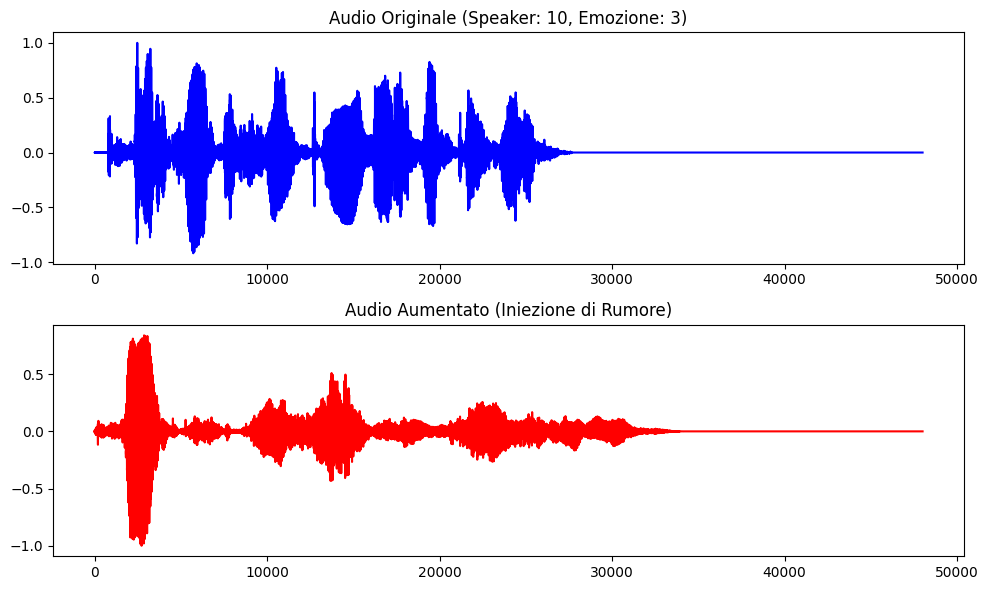

In [13]:
import matplotlib.pyplot as plt

# Seleziona un campione a caso dal tuo nuovo dataset aumentato
idx = 3
waveform, sample_rate, label, speaker_id, _ = train_dataset[idx] # Originale
waveform_noise, _, _, _, _ = train_dataset[idx + 3] # Supponendo che qui ci sia quello con Background Noise

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Plot Originale
axs[0].plot(waveform[0].numpy(), color='blue')
axs[0].set_title(f"Audio Originale (Speaker: {speaker_id}, Emozione: {label.item()})")

# Plot Aumentato (es. con Rumore)
axs[1].plot(waveform_noise[0].numpy(), color='red')
axs[1].set_title("Audio Aumentato (Iniezione di Rumore)")

plt.tight_layout()
plt.show()

In [14]:
print(f" Speaker {speaker_id} saying '{label}'")
print()
#Ascolta lo stesso campione con "ipd.Audio(<forma d'onda>, )"
ipd.display(ipd.Audio(waveform.numpy(), rate=sample_rate))

 Speaker 10 saying '3'



Run the following cell and listen to the sample

# Formatting the data
Functions `label_to_index` and `index_to_label` are used to map (and encode) each word with its index in the list of labels.

In [15]:

# 1. Creiamo la mappa inversa
inverse_emotion_map = {v.lower(): k for k, v in emotion_map.items()}

def label_to_index(word):
    return torch.tensor(inverse_emotion_map[word.lower()])

def index_to_label(index):
    if torch.is_tensor(index): index = index.item()
    return emotion_map.get(index, f"Unknown ({index})")

# Test
w = 'Calm'; print(f"{w} → {label_to_index(w)} → {index_to_label(label_to_index(w))}")


Calm → 1 → calm


In [16]:
import torchaudio.transforms as T
import torchvision

n_fft = 512
win_length = 400
hop_length = 160
n_mels = 128
resample_freq = 16000

specgramFn = T.Spectrogram(n_fft=n_fft, win_length=win_length, hop_length=hop_length, power=2.0)
melscaleFn = T.MelScale(n_mels=n_mels, sample_rate=resample_freq, n_stft=n_fft//2+1)
amplitude_to_db_transform = T.AmplitudeToDB(stype='power', top_db=80)
_resizeFn = torchvision.transforms.Resize((64, 128))

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


### collate_fn e DataLoaders

> **Miglioramento:** `num_workers` portato a 2 su CPU, 4 su GPU.

In [17]:
_resizeFn = torchvision.transforms.Resize((64, 128))

def pad_sequence(batch):
    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)
    return batch.permute(0, 2, 1)


def collate_fn(batch):
    tensors, targets = [], []
    for data in batch:
        tensors.append(data[0])
        targets.append(data[2])

    padded_waveforms = pad_sequence(tensors)
    spec_tensors    = specgramFn(padded_waveforms)
    melspec_tensors = melscaleFn(spec_tensors)
    db_melspec      = amplitude_to_db_transform(melspec_tensors)
    mel             = _resizeFn(db_melspec)
    targets         = torch.stack(targets)
    return mel, targets


batch_size = 64

# Miglioramento: num_workers aumentato per velocizzare il caricamento
if device.type == "cuda":
    num_workers = 4
    pin_memory  = True
else:
    num_workers = 2
    pin_memory  = False

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    collate_fn=collate_fn, num_workers=num_workers, pin_memory=pin_memory,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, drop_last=False,
    collate_fn=collate_fn, num_workers=num_workers, pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, drop_last=False,
    collate_fn=collate_fn, num_workers=num_workers, pin_memory=pin_memory,
)


### Calcolo dei pesi per le classi (class weighting)

> **Nuovo:** RAVDESS ha classi sbilanciate. `CrossEntropyLoss` con pesi bilancia il contributo di ogni emozione.

In [18]:
from sklearn.utils.class_weight import compute_class_weight

# Raccogliamo tutte le label del train set per calcolare i pesi
print("Raccolta label del train set per class weighting...")
all_train_labels = []
for fp in train_dataset.file_paths:
    _, _, emotion_label, _ = torch.load(fp, weights_only=False)
    all_train_labels.append(emotion_label)

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(8),
    y=all_train_labels
)
weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Pesi per classe:")
for i, w in enumerate(class_weights_np):
    print(f"  {emotion_map[i]:10s}: {w:.4f}")


Raccolta label del train set per class weighting...
Pesi per classe:
  neutral   : 1.4612
  calm      : 0.9968
  happy     : 1.0243
  sad       : 0.7157
  angry     : 1.0243
  fearful   : 1.0104
  disgust   : 0.9968
  surprised : 1.0314


# Generic functions for training and testing the network model

Now let's define a *generic* training function that will feed our training data into the model and perform the backward pass and optimization steps.

In [19]:

def train(model, transform, criterion, optimizer, epoch, log_interval, scheduler=None):
    """
    Esegue una epoca di training.
    Nota: lo scheduler NON viene aggiornato qui; viene aggiornato una sola volta per epoca
    nella cella principale di training.
    """
    model.train()
    running_loss = 0.0

    batch_iterator = tqdm(train_loader, desc=f"Train epoch {epoch}", leave=False)

    for batch_idx, (data, target) in enumerate(batch_iterator):
        data, target = data.to(device), target.to(device)

        # Applica SpecAugment solo sul training set
        data = spec_augment(data)

        if transform is not None:
            data = data.contiguous()
            data = transform(data)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        batch_iterator.set_postfix(loss=f"{loss.item():.4f}")

        if batch_idx % log_interval == 0:
            print(
                f"  Train Epoch: {epoch} "
                f"[{batch_idx * len(data)}/{len(train_loader.dataset)} "
                f"({100. * batch_idx / len(train_loader):.0f}%)]  "
                f"Loss: {loss.item():.6f}"
            )

    return running_loss / len(train_loader)


In [20]:

def number_of_correct(pred, target):
    # count number of correct predictions
    return pred.squeeze().eq(target).sum().item()


def get_likely_index(tensor):
    # find most likely label index for each element in the batch
    return tensor.argmax(dim=-1)


def test(model, transform, criterion, epoch):
    """
    Funzione mantenuta solo per compatibilità con il notebook.
    Per il flusso finale usa evaluate(...), non questa funzione.
    """
    test_acc, test_loss = evaluate(model, test_loader, criterion, split='Test')
    print(f"\nTest Epoch: {epoch}\tLoss: {test_loss:.4f}\tAccuracy: {test_acc:.1f}%\n")
    return test_acc, test_loss


In [21]:
def evaluate(model, loader, criterion, split='Val'):
    model.eval()
    total_loss, correct = 0.0, 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            total_loss += criterion(output, target).item()
            correct += output.argmax(dim=-1).eq(target).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / len(loader.dataset)
    print(
        f'  [{split}] Loss: {avg_loss:.4f}  '
        f'Accuracy: {correct}/{len(loader.dataset)} ({accuracy:.1f}%)'
    )
    return accuracy, avg_loss


def compute_split_metrics(model, loader, criterion, device, transform=None):
    """
    Calcola loss media, accuracy ed error rate su uno split.
    Non applica SpecAugment: in validazione/test e nella stima finale
    vogliamo valutare il modello sui dati non perturbati.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    n_samples = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            if transform is not None:
                data = data.contiguous()
                data = transform(data)

            output = model(data)
            loss = criterion(output, target)

            batch_size = target.size(0)
            total_loss += loss.item()
            correct += output.argmax(dim=-1).eq(target).sum().item()
            n_samples += batch_size

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / n_samples
    error = 100.0 - accuracy

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'error': error,
        'correct': correct,
        'total': n_samples,
    }


def print_error_summary(model, criterion, device, transform=None):
    """
    Stampa un riepilogo finale train/validation/test.
    Serve per diagnosticare bias e varianza:
    - train error alto  -> possibile bias/underfitting
    - gap val-test/train alto -> possibile varianza/overfitting
    """
    split_loaders = {
        'train': train_loader,
        'val': val_loader,
        'test': test_loader,
    }

    metrics = {}
    print("\n" + "=" * 50)
    print("SUMMARY FINALE: TRAIN / VALIDATION / TEST")
    print("=" * 50)

    for split_name, loader in split_loaders.items():
        split_metrics = compute_split_metrics(
            model=model,
            loader=loader,
            criterion=criterion,
            device=device,
            transform=transform,
        )
        metrics[f'{split_name}_loss'] = split_metrics['loss']
        metrics[f'{split_name}_acc'] = split_metrics['accuracy']
        metrics[f'{split_name}_error'] = split_metrics['error']

        print(
            f"{split_name.upper():>10} | "
            f"loss={split_metrics['loss']:.4f} | "
            f"acc={split_metrics['accuracy']:.2f}% | "
            f"error={split_metrics['error']:.2f}% "
            f"({split_metrics['correct']}/{split_metrics['total']})"
        )

    metrics['generalization_gap_val'] = metrics['val_error'] - metrics['train_error']
    metrics['generalization_gap_test'] = metrics['test_error'] - metrics['train_error']

    print("-" * 50)
    print(f"Gap val-train error:  {metrics['generalization_gap_val']:.2f}%")
    print(f"Gap test-train error: {metrics['generalization_gap_test']:.2f}%")
    print("=" * 50)

    return metrics


def evaluate_model(model, loader, device, transform=None, classes=None, split_name='Test'):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            if transform is not None:
                data = data.contiguous()
                data = transform(data)

            output = model(data)
            preds = output.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    # --- CALCOLO METRICHE RICHIESTE DAL PROGETTO ---
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')
    cm = confusion_matrix(all_targets, all_preds)

    print("\n" + "=" * 40)
    print(f"RISULTATI FINALI SULLO SPLIT: {split_name.upper()}")
    print("=" * 40)
    print(f"Accuracy Generale: {acc * 100:.2f}%")
    print(f"F1-Score (Macro): {f1:.4f}")

    if classes is None:
        classes = [emotion_map[i] for i in range(len(cm))]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel('Predizione del Modello')
    plt.ylabel('Emozione Reale')
    plt.title(f'Matrice di Confusione - {split_name}')
    plt.tight_layout()
    plt.show()

    return acc, f1, cm


## Mel spectrogram model (with 2D transformation)
**Task: Mel Spectrogram Transform.** Starting from the data visualization section where the Mel Spectrogram of a sample has been computed, build _transform pipeline_ to convert the audio samples to the Mel spectrogram representation.

* H: check the shape of the 2D array before using it as input to the model, i.e. the number of bins (values) both in the time and frequency domain.



La forma (shape) del tensore finale dbmelspec sarà generalmente nel formato:$$\text{Shape} = (\text{Canali}, \text{Bande Mel}, \text{Frame Temporali})$$
1. Dominio della Frequenza (Asse Y)
- Numero di Bins in Frequenza: Corrisponde al parametro n_mels.
- Valore: 128.
- Significato: Questo è il numero di caratteristiche che il modello vedrà nel dominio della frequenza logaritmica. Ogni riga del tuo spettrogramma rappresenta una banda Mel
2. Dominio del Tempo (Asse X)
- Numero di Bins nel Tempo (Frame): Dipende dalla lunghezza totale della forma d'onda ($\text{Lunghezza}$) e dai parametri n_fft e hop_length.
- Formula: Il numero di frame temporali ($N_{\text{frame}}$) è calcolato approssimativamente come:$$N_{\text{frame}} \approx \lfloor \frac{\text{Lunghezza} - \text{n\_fft}}{\text{hop\_length}} \rfloor + 1$$
- Significato: Questo è il numero di "fotogrammi" temporali dello spettrogramma. Ogni colonna del tuo spettrogramma rappresenta una finestra di tempo che si sposta di $10\ \text{ms}$ (hop_length).

Per i modelli di Deep Learning, il tensore bidimensionale (128 Bande Mel $\times$ X Frame) è l'input principale.

# Network Model

In [22]:

import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()
        # Prende ogni hidden state (68 numeri) e produce 1 score
        # hidden_size = 68 perché è rnn_hidden della GRU
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, rnn_outputs):
        # rnn_outputs: (batch_size, 16, 68)
        #   - batch_size: quanti audio nel batch (es. 64)
        #   - 16: timestep (finestre temporali dopo la CNN+GRU)
        #   - 68: dimensione hidden state della GRU

        # Step 1: calcola uno score per ogni timestep
        scores = self.attention(rnn_outputs)       # (B, 16, 1)

        # Step 2: trasforma gli score in pesi che sommano a 1
        weights = F.softmax(scores, dim=1)         # (B, 16, 1)

        # Step 3: moltiplica ogni hidden state per il suo peso
        weighted_outputs = weights * rnn_outputs   # (B, 16, 68)

        # Step 4: somma tutto → vettore riassuntivo
        context_vector = torch.sum(weighted_outputs, dim=1)  # (B, 68)

        # Restituisce anche i pesi: utili per visualizzare dove guarda il modello
        return context_vector, weights


class CRNN(nn.Module):
    """
    CRNN Architecture con Attention Layer.

    Flusso:
        Input mel-spectrogram
            - 4x Conv2D (3x3) + BatchNorm + ELU + MaxPool + Dropout
            - AdaptiveAvgPool2d → (freq=1, time=16)  [era 8: più contesto temporale]
            - 2-layer GRU
            - AttentionLayer (focus sui frame importanti)  ← NUOVO
            -  - Last hidden state → FC → num_classes

    Input:  (batch, 1, 64, 128)   — (B, canali, mel_bins, time_frames)
    Output: (batch, 8)            — logit per le 8 emozioni
    """

    def __init__(self, num_classes: int, n_channels: int = 68,
                 rnn_hidden: int = 68, rnn_layers: int = 2,
                 dropout: float = 0.3):
        super().__init__()

        # ── Blocco CNN 1 
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, n_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout(dropout),
        )

        # ── Blocco CNN 2
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(n_channels, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout(dropout),
        )

        # ── Blocco CNN 3 
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),
            nn.Dropout(dropout),
        )

        # ── Blocco CNN 4
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),
            nn.Dropout(dropout),
        )

        # ── Pooling
        # Forza l'output a (B, 136, 1, 16) indipendentemente dall'input
        # freq=1: collassa tutta la dimensione frequenza in 1
        # time=16: mantiene 16 timestep da dare alla GRU
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 16))

        # ── GRU
        # input_size=136: ogni timestep ha 136 feature (canali CNN)
        # hidden_size=68: ogni hidden state ha 68 numeri
        # num_layers=2: due GRU impilate
        # batch_first=True: il batch è la prima dimensione
        self.rnn = nn.GRU(
            input_size=n_channels * 2,   # 136
            hidden_size=rnn_hidden,       # 68
            num_layers=rnn_layers,        # 2
            batch_first=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )

        # ── Attention Layer
        # hidden_size=rnn_hidden=68: deve matchare l'output della GRU
        self.attention_layer = AttentionLayer(hidden_size=rnn_hidden)

        # ── Classificatore
        # Da 68 (context vector) a 8 (emozioni)
        self.fc = nn.Linear(rnn_hidden, num_classes)

    def forward(self, x):
        # x: (B, 1, 64, 128)

        
        x = self.conv_block1(x)   # (B, 68,  32, 64)
        x = self.conv_block2(x)   # (B, 136, 16, 32)
        x = self.conv_block3(x)   # (B, 136,  4, 16)
        x = self.conv_block4(x)   # (B, 136,  1,  8)

        
        x = self.adaptive_pool(x)  # (B, 136, 1, 16)

        # ── Reshape per la GRU
        x = x.squeeze(2)           # (B, 136, 16) — rimuove la dim frequenza=1
        x = x.permute(0, 2, 1)    # (B, 16, 136) — GRU vuole (B, seq, features)

        # ── GRU
        # rnn_out: (B, 16, 68) — hidden state per TUTTI i 16 timestep
        # NON usiamo più h_n[-1] (solo l'ultimo): vogliamo tutti i timestep
        rnn_out, _ = self.rnn(x)

        # ── Attention
        # context: (B, 68) — riassunto pesato di tutti i timestep
        # attn_weights: (B, 16, 1) — quanto "guarda" ogni timestep
        context, attn_weights = self.attention_layer(rnn_out)

        # ── Classificazione finale
        return self.fc(context)    # (B, 8)


# ── Verifica

NUMERO_EMOZIONI = 8

model_crnn = CRNN(
    num_classes=NUMERO_EMOZIONI,
    n_channels=68,
    rnn_hidden=68,
    rnn_layers=2,
    dropout=0.3
)

_dummy = torch.zeros(2, 1, 64, 128)
with torch.no_grad():
    _out = model_crnn(_dummy)

print(f"Shape check → input: {list(_dummy.shape)}  output: {list(_out.shape)}")
assert _out.shape == (2, NUMERO_EMOZIONI), "Shape mismatch!"
print("Forward pass OK")

total_params = sum(p.numel() for p in model_crnn.parameters() if p.requires_grad)
print(f"Parametri totali: {total_params:,}")
print()
print(model_crnn)



Shape check → input: [2, 1, 64, 128]  output: [2, 8]
Forward pass OK
Parametri totali: 488,997

CRNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 68, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(68, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(68, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(136, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(136, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(136, eps=1e-05, momentum=0.1, affine=True, track_running_stats

## Training

> **Miglioramenti applicati:**
> - **`AdamW`** con `weight_decay=1e-4` (migliore regolarizzazione rispetto ad Adam)
> - **`ReduceLROnPlateau`** adattivo sulla val_loss (era `StepLR` cieco ogni 10 epoche)
> - **`CrossEntropyLoss`** con `weight=weight_tensor` + `label_smoothing=0.1`
> - **Salvataggio su disco** del best model dopo ogni miglioramento

In [23]:
import torch.optim as optim
from tqdm import tqdm
import copy
import numpy as np
import os

BEST_MODEL_PATH = '/kaggle/working/best_crnn_model.pth'

# ── Iperparametri ─────────────────────────────────────────────────────────────
epochs        = 50
log_interval  = 10
learning_rate = 0.0005

# Early stopping
patience           = 7
min_delta          = 1e-4
early_stop_counter = 0

best_val_loss = np.inf
best_val_acc  = 0.0
best_state    = None
best_epoch    = 0

model = model_crnn.to(device)

# Miglioramento 1: CrossEntropyLoss con pesi di classe + label smoothing
criterion = nn.CrossEntropyLoss(
    weight=weight_tensor,     # bilancia le classi sbilanciate
    label_smoothing=0.1       # riduce l'overconfidence
)

# Miglioramento 2: AdamW con weight decay (migliore generalizzazione rispetto ad Adam)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Miglioramento 3: ReduceLROnPlateau adattivo sulla val_loss
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"Inizio Addestramento su dispositivo: {device}")
print("=" * 40)

for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")

    train_loss = train(
        model, transform=None, criterion=criterion,
        optimizer=optimizer, epoch=epoch, log_interval=log_interval,
        scheduler=None
    )

    val_acc, val_loss = evaluate(model, val_loader, criterion, split='Val')

    # Miglioramento: scheduler step sulla val_loss (era step fisso ogni 10 epoche)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_val_acc  = val_acc
        best_state    = copy.deepcopy(model.state_dict())
        best_epoch    = epoch
        early_stop_counter = 0

        # Miglioramento: salvataggio su disco (era solo in RAM)
        torch.save(best_state, BEST_MODEL_PATH)
        print(
            f"  ✅ Nuovo best model salvato su disco "
            f"(epoch {epoch}, val_loss={val_loss:.4f}, val_acc={val_acc:.1f}%)"
        )
    else:
        early_stop_counter += 1
        print(f"  Nessun miglioramento ({early_stop_counter}/{patience})")

    if early_stop_counter >= patience:
        print(f"\nEarly stopping attivato alla epoch {epoch}.")
        break

print(
    f"\nTraining completato. "
    f"Best epoch: {best_epoch}, "
    f"Best val loss: {best_val_loss:.4f}, "
    f"Best val acc: {best_val_acc:.1f}%"
)

# Test finale con il best model
if best_state is None:
    raise RuntimeError("Nessun best_state salvato: controlla validation loader/loss.")

model.load_state_dict(best_state)
test_acc, test_loss = evaluate(model, test_loader, criterion, split='Test')
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Acc:  {test_acc:.1f}%")


Inizio Addestramento su dispositivo: cuda

Epoch 1/50


Train epoch 1:   0%|          | 3/632 [00:02<07:32,  1.39it/s, loss=2.0797]

  Train Epoch: 1 [0/40398 (0%)]  Loss: 2.076464


Train epoch 1:   2%|▏         | 13/632 [00:03<01:18,  7.91it/s, loss=2.1043]

  Train Epoch: 1 [640/40398 (2%)]  Loss: 2.093124


...

  Train Epoch: 17 [39040/40398 (97%)]  Loss: 0.629482


Train epoch 17:  98%|█████████▊| 621/632 [01:31<00:01,  7.75it/s, loss=0.6067]

  Train Epoch: 17 [39680/40398 (98%)]  Loss: 0.755615


  Train Epoch: 17 [40320/40398 (100%)]  Loss: 0.697562


  [Val] Loss: 1.1883  Accuracy: 344/498 (69.1%)
  Nessun miglioramento (7/7)

Early stopping attivato alla epoch 17.

Training completato. Best epoch: 10, Best val loss: 1.1502, Best val acc: 69.5%
  [Test] Loss: 1.4715  Accuracy: 132/248 (53.2%)
Final Test Loss: 1.4715
Final Test Acc:  53.2%


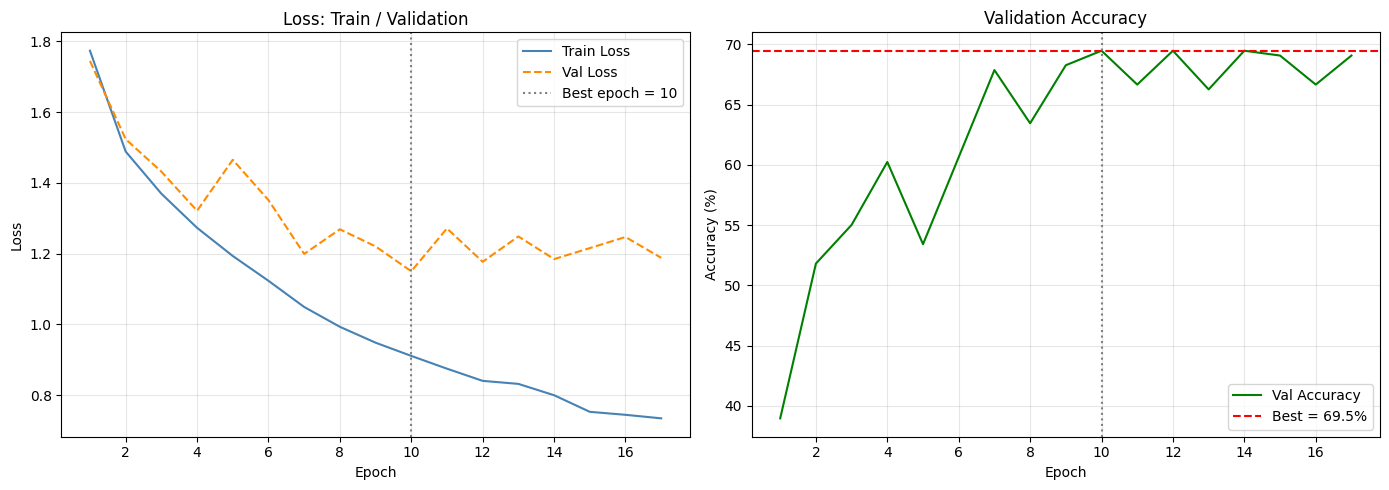

In [24]:

epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grafico 1: Train / Validation Loss ─────────────────────────────────────
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='darkorange', linestyle='--')

if best_epoch > 0:
    axes[0].axvline(best_epoch, color='gray', linestyle=':', label=f'Best epoch = {best_epoch}')

axes[0].set_title('Loss: Train / Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Grafico 2: Validation Accuracy ──────────────────────────────────────────
axes[1].plot(epochs_range, history['val_acc'], color='green', label='Val Accuracy')
axes[1].axhline(
    y=best_val_acc,
    color='red',
    linestyle='--',
    label=f'Best = {best_val_acc:.1f}%'
)

if best_epoch > 0:
    axes[1].axvline(best_epoch, color='gray', linestyle=':')

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



SUMMARY FINALE: TRAIN / VALIDATION / TEST
     TRAIN | loss=0.5712 | acc=97.06% | error=2.94% (39210/40398)
       VAL | loss=1.1502 | acc=69.48% | error=30.52% (346/498)
      TEST | loss=1.4715 | acc=53.23% | error=46.77% (132/248)
--------------------------------------------------
Gap val-train error:  27.58%
Gap test-train error: 43.83%

Avoidable bias stimato con human-level error=5.0%: 0.00%


RISULTATI FINALI SULLO SPLIT: VALIDATION
Accuracy Generale: 69.48%
F1-Score (Macro): 0.6892


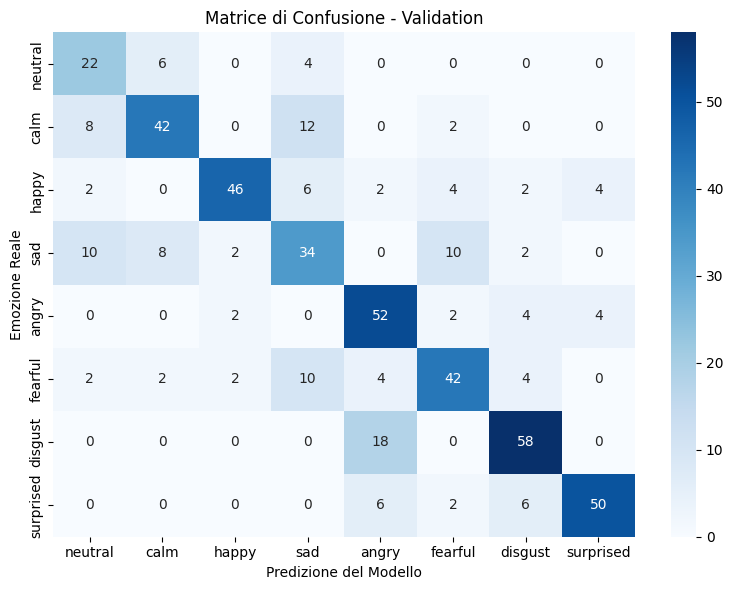



RISULTATI FINALI SULLO SPLIT: TEST
Accuracy Generale: 53.23%
F1-Score (Macro): 0.4996


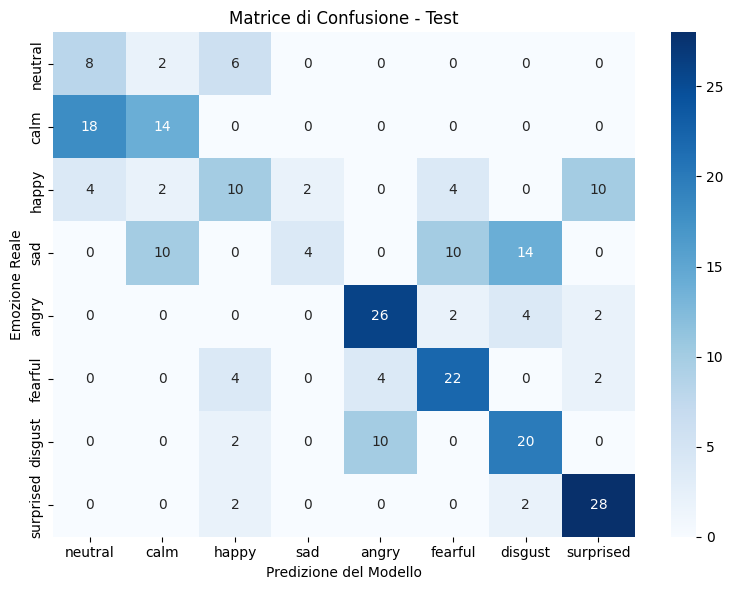

In [25]:

import os
# Ricarica il modello migliore salvato durante il training.
# In questo notebook il best model viene salvato in memoria come best_state.
# Se è stato salvato anche su disco, viene caricato da BEST_MODEL_PATH.
if 'BEST_MODEL_PATH' in globals() and os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
elif 'best_state' in globals() and best_state is not None:
    model.load_state_dict(best_state)
else:
    raise RuntimeError(
        "Best model non disponibile. Esegui prima la cella di training "
        "oppure salva il best model in BEST_MODEL_PATH."
    )

model.to(device)
model.eval()

classes = [emotion_map[i] for i in range(8)]

# Summary finale con training/validation/test error.
# Questo serve per calcolare bias evitabile e varianza.
final_metrics = print_error_summary(
    model=model,
    criterion=criterion,
    device=device,
    transform=None
)

# Stima opzionale del bias evitabile con human-level error realistico
human_error = 5.0  # puoi modificare questo valore nella relazione
avoidable_bias = max(0, final_metrics['train_error'] - human_error)
print(
    f"\nAvoidable bias stimato con human-level error={human_error:.1f}%: "
    f"{avoidable_bias:.2f}%"
)

# Evaluate on the validation set con F1 e confusion matrix
print()
val_acc_final, val_f1_final, val_cm = evaluate_model(
    model,
    val_loader,
    device,
    transform=None,
    classes=classes,
    split_name='Validation'
)

# Evaluate on the test set, una sola volta alla fine
print()
test_acc_final, test_f1_final, test_cm = evaluate_model(
    model,
    test_loader,
    device,
    transform=None,
    classes=classes,
    split_name='Test'
)